<a href="https://colab.research.google.com/github/xoxoreyniel/DSC1105/blob/main/SEC1_DSC1105_G4_Awit%2C_JT%3B_Deloyola%2C_JR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#I. Analyzing Reproductive Health and Behavior Patterns Using NSFG 2022–2023 (50 Points)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




=== TASK 4A: POISSON REGRESSION ===

Call:
glm(formula = preg_count ~ age + marital_status, family = "poisson", 
    data = df_clean)

Coefficients:
                                          Estimate Std. Error z value Pr(>|z|)
(Intercept)                              -1.083834   0.059940 -18.082   <2e-16
age                                       0.046655   0.001454  32.095   <2e-16
marital_statusMarried                     0.069238   0.035257   1.964   0.0496
marital_statusNever Married              -0.613202   0.039508 -15.521   <2e-16
marital_statusSeparated/Divorced/Widowed  0.064922   0.045846   1.416   0.1568
                                            
(Intercept)                              ***
age                                      ***
marital_statusMarried                    *  
marital_statusNever Married              ***
marital_statusSeparated/Divorced/Widowed    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson fami

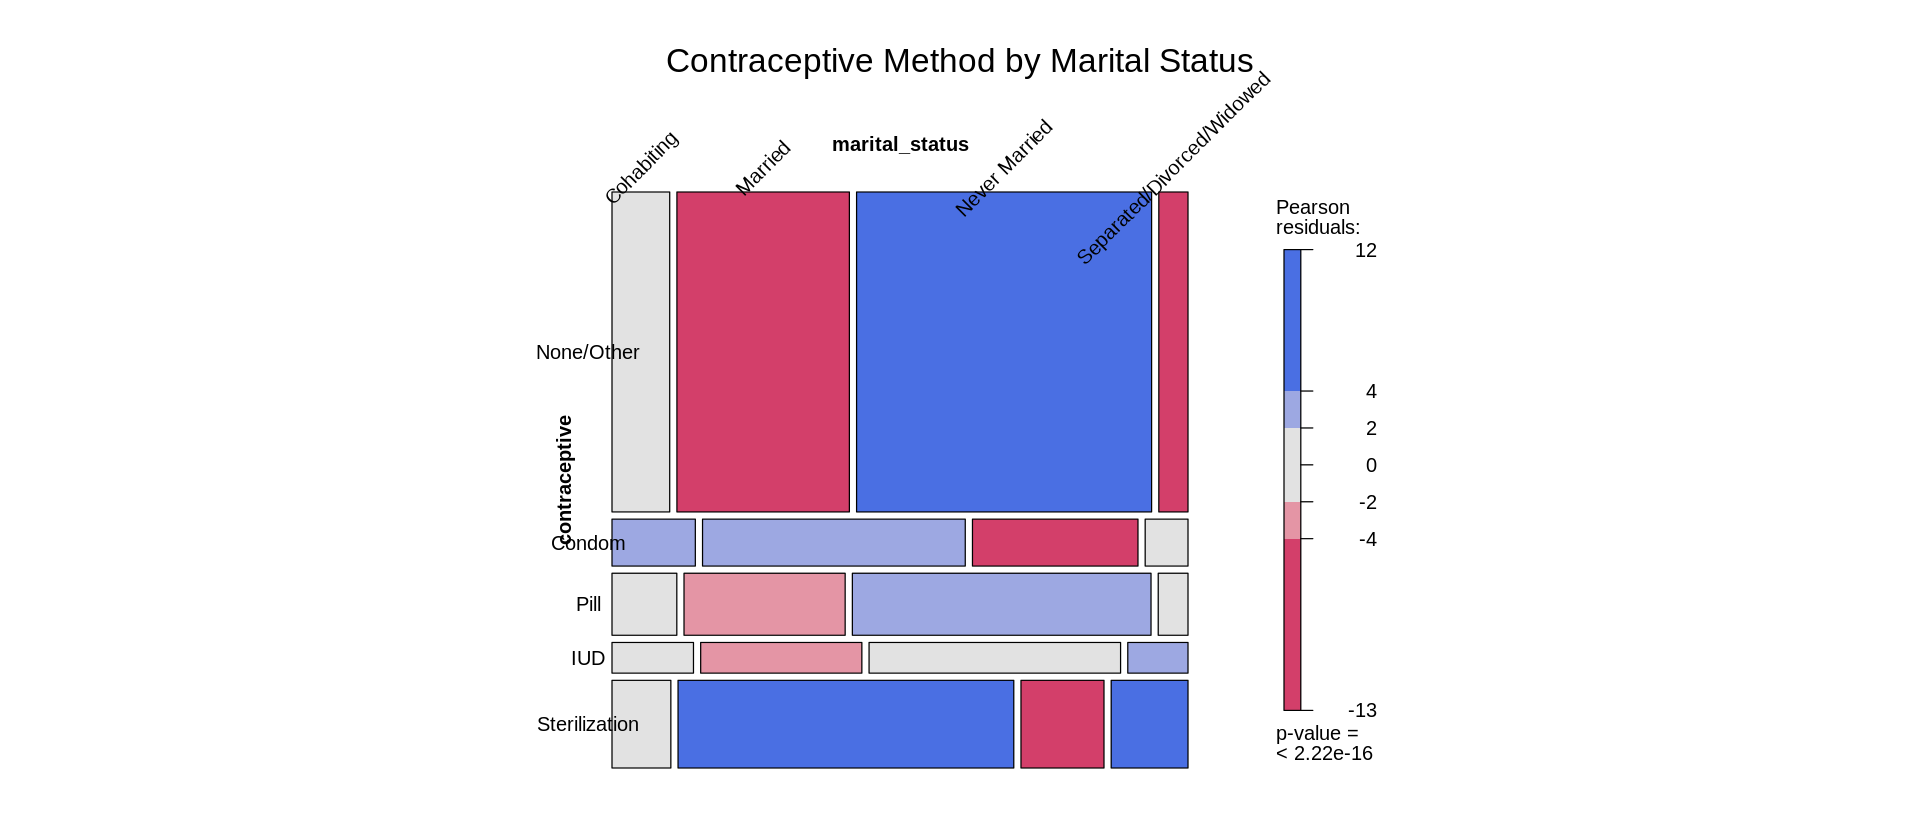

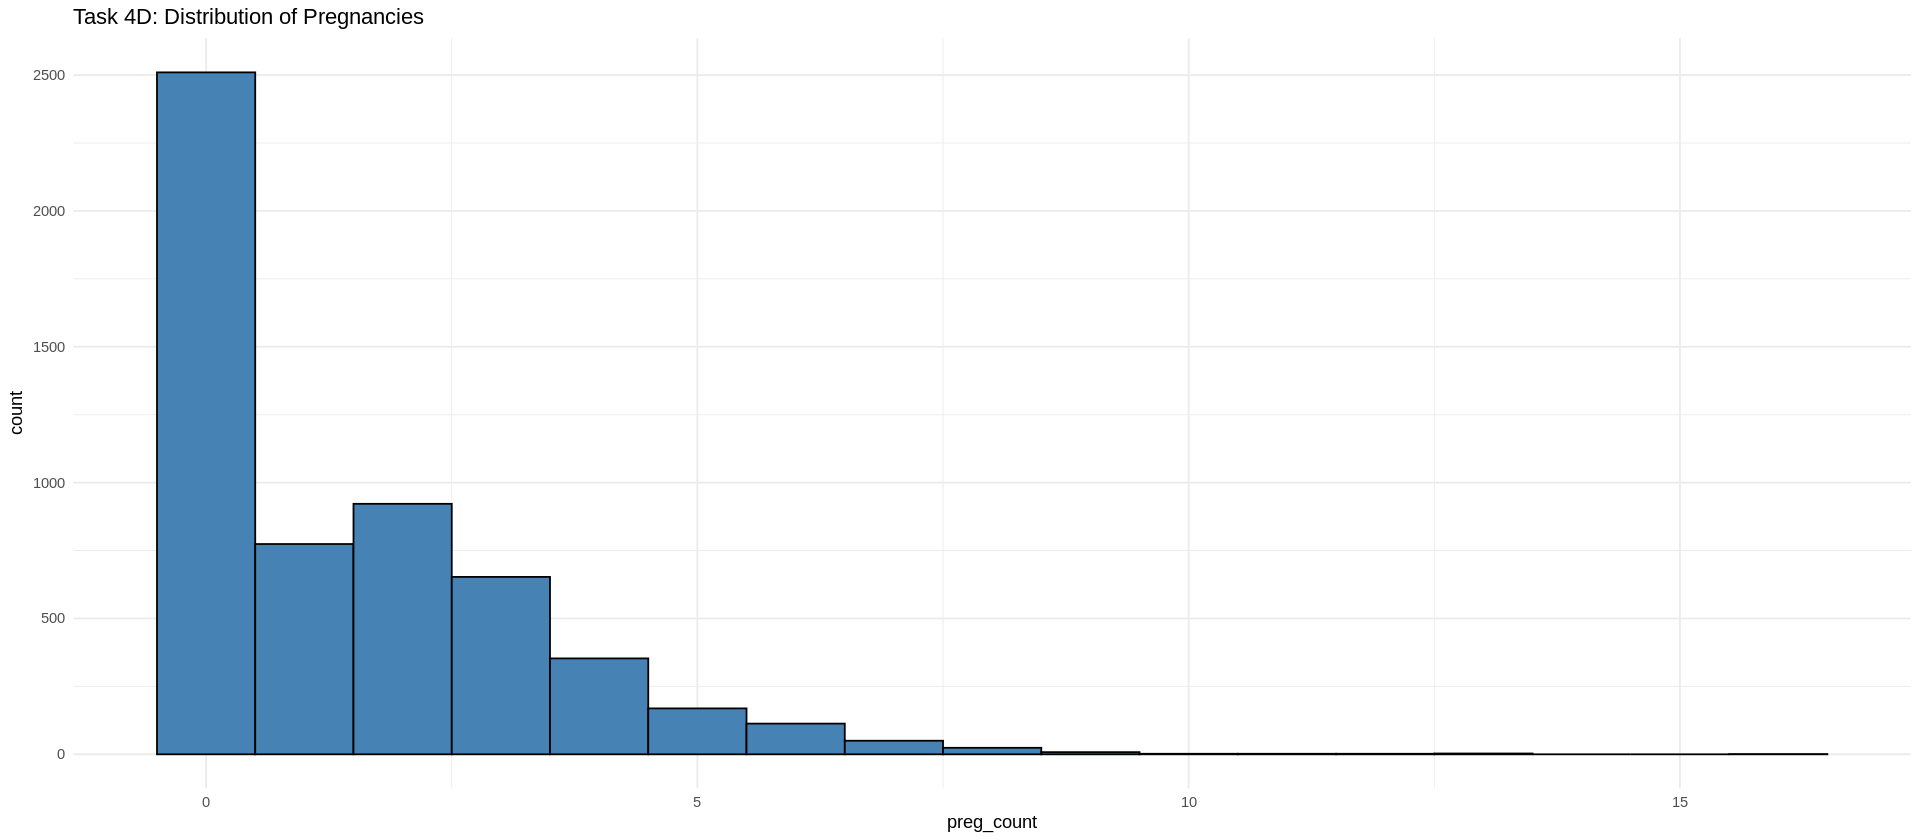


--- ANOVA Results ---
                Df Sum Sq Mean Sq F value Pr(>F)    
contraceptive    4  75011   18753     242 <2e-16 ***
Residuals     5581 432502      77                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- Pairwise Comparisons (Bonferroni) ---

	Pairwise comparisons using t tests with pooled SD 

data:  df_clean$age and df_clean$contraceptive 

              None/Other Condom  Pill    IUD    
Condom        8.5e-16    -       -       -      
Pill          1.00       1.4e-12 -       -      
IUD           < 2e-16    0.85    1.2e-15 -      
Sterilization < 2e-16    < 2e-16 < 2e-16 < 2e-16

P value adjustment method: bonferroni 

--- Pairwise Comparisons (FDR) ---

	Pairwise comparisons using t tests with pooled SD 

data:  df_clean$age and df_clean$contraceptive 

              None/Other Condom  Pill    IUD    
Condom        < 2e-16    -       -       -      
Pill          0.352      1.8e-13 -       -      
IUD           < 2e-16    0.094   <

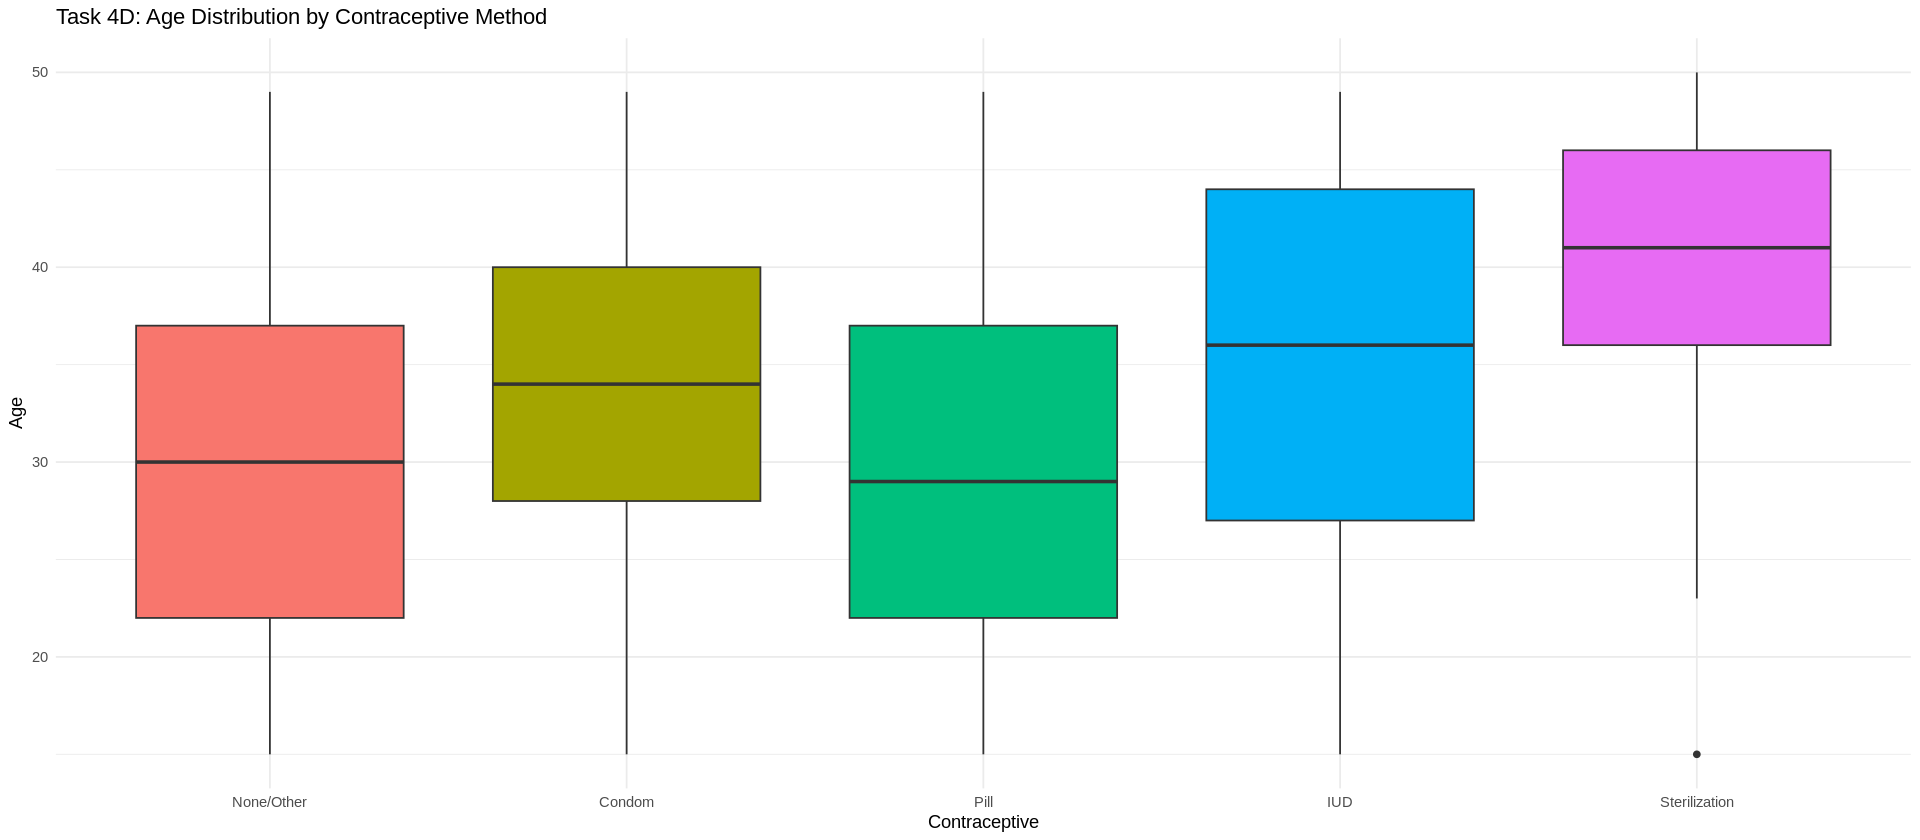

In [29]:
# Install necessary packages if you haven't already
install.packages(c("MASS", "nnet", "vcd"))
library(tidyverse)
library(MASS)  # For Ordinal Logistic Regression (polr)
library(nnet)  # For Multinomial Logistic Regression (multinom)
library(vcd)   # For Mosaic Plots

df <- read.csv("/content/NSFG_2022_2023_FemRespPUFData.csv")

# Clean, Recode, and Factor Variables
df_clean <- df %>%
  filter(!is.na(PREGNUM) & !is.na(HIEDUC) & !is.na(CONSTAT1) & !is.na(RMARITAL)) %>%
  mutate(
    # Count Variable
    preg_count = as.numeric(PREGNUM),

    # Demographic Variables
    age = as.numeric(AGER),
    marital_status = case_when(
      RMARITAL == 1 ~ "Married",
      RMARITAL == 2 ~ "Cohabiting",
      RMARITAL %in% c(3, 4, 5) ~ "Separated/Divorced/Widowed",
      RMARITAL == 6 ~ "Never Married",
      TRUE ~ "Other"
    ),
    marital_status = as.factor(marital_status),

    # Nominal Variable: Group Contraceptive Methods
    contraceptive = case_when(
      CONSTAT1 == 6 ~ "Pill",
      CONSTAT1 == 10 ~ "Condom",
      CONSTAT1 == 33 ~ "IUD",
      CONSTAT1 %in% c(1, 2) ~ "Sterilization",
      TRUE ~ "None/Other"
    ),
    contraceptive = factor(contraceptive, levels = c("None/Other", "Condom", "Pill", "IUD", "Sterilization")),

    # Ordinal Variable: Group Education into ordered factors (FIXED FOR CDC PUF TOP-CODING)
    education = case_when(
      HIEDUC <= 8 ~ "High School or Less",
      HIEDUC %in% c(9, 10) ~ "Some College / Associate's",
      HIEDUC >= 11 ~ "Bachelor's Degree or Higher",
      TRUE ~ NA_character_
    ),
    education = factor(education,
                       levels = c("High School or Less", "Some College / Associate's", "Bachelor's Degree or Higher"),
                       ordered = TRUE)
  ) %>% drop_na(education)


# --- TASK 4A: POISSON REGRESSION ---
cat("\n=== TASK 4A: POISSON REGRESSION ===\n")
poisson_model <- glm(preg_count ~ age + marital_status, family = "poisson", data = df_clean)
print(summary(poisson_model))

dispersion_ratio <- poisson_model$deviance / poisson_model$df.residual
cat("Dispersion Ratio (Deviance/DF):", round(dispersion_ratio, 3), "\n")


# --- TASK 4B: CONTINGENCY TABLES & CHI-SQUARE ---
cat("\n TASK 4B: CONTINGENCY TABLES \n")
contingency_table <- table(df_clean$contraceptive, df_clean$marital_status)
print(contingency_table)

chi_test <- chisq.test(contingency_table)
print(chi_test)

mosaic(~ contraceptive + marital_status, data = df_clean, shade = TRUE,
       main = "Contraceptive Method by Marital Status",
       labeling = labeling_border(rot_labels = c(45,0,0,0)))

# --- TASK 4C: CATEGORICAL RESPONSE MODELING ---
cat("\nTASK 4C-1: ORDINAL LOGISTIC REGRESSION \n")
ordinal_model <- polr(education ~ age + preg_count, data = df_clean, Hess = TRUE)
print(summary(ordinal_model))

cat("\nOrdinal Odds Ratios:\n")
print(exp(coef(ordinal_model)))


cat("\n TASK 4C-2: MULTINOMIAL LOGISTIC REGRESSION \n")
multinom_model <- multinom(contraceptive ~ age, data = df_clean, trace = FALSE)
print(summary(multinom_model))

cat("\nMultinomial Odds Ratios:\n")
print(exp(coef(multinom_model)))


# --- TASK 4D: EDA & MULTIPLE COMPARISONS ---
cat("\n 4D: EDA & MULTIPLE COMPARISONS\n")

# EDA Plot 1: Histogram
plot_hist <- ggplot(df_clean, aes(x = preg_count)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "black") +
  theme_minimal() + labs(title = "Task 4D: Distribution of Pregnancies")
print(plot_hist)

# EDA Plot 2: Boxplot
plot_box <- ggplot(df_clean, aes(x = contraceptive, y = age, fill = contraceptive)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Task 4D: Age Distribution by Contraceptive Method", x = "Contraceptive", y = "Age") +
  theme(legend.position = "none")
print(plot_box)

# Multiple Comparisons (ANOVA)
cat("\n--- ANOVA Results ---\n")
anova_model <- aov(age ~ contraceptive, data = df_clean)
print(summary(anova_model))

# Adjust p-values
cat("\n--- Pairwise Comparisons (Bonferroni) ---\n")
pairwise_bonf <- pairwise.t.test(df_clean$age, df_clean$contraceptive, p.adjust.method = "bonferroni")
print(pairwise_bonf)

cat("\n--- Pairwise Comparisons (FDR) ---\n")
pairwise_fdr <- pairwise.t.test(df_clean$age, df_clean$contraceptive, p.adjust.method = "fdr")
print(pairwise_fdr)

# II. Principal Component Analysis of TF-IDF Article Data (30 Points)

combined numbers 1 and 2

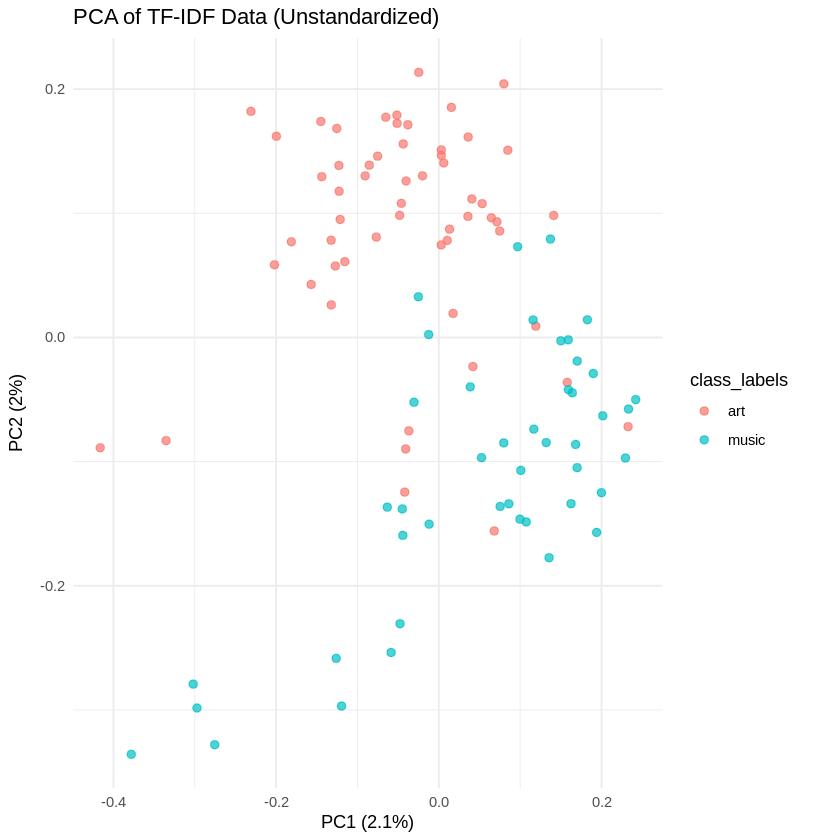

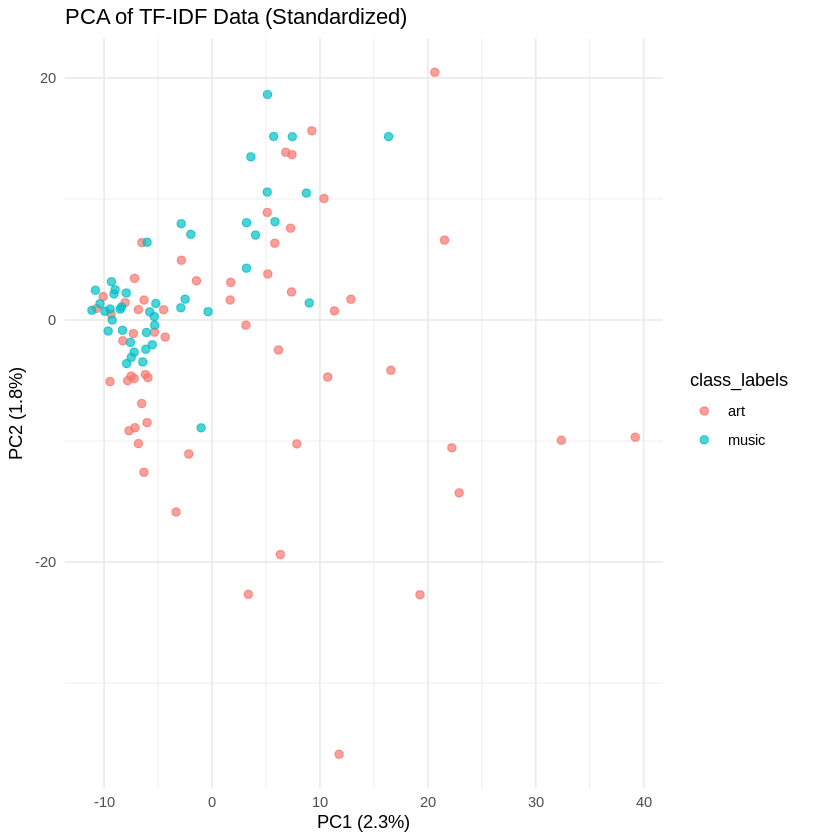

In [7]:
library(tidyverse)
df <- read.csv("/content/nyt_articles-1 (2).csv")

# 1. isolate the target variable (labels)
labels <- df$class.labels

# 2. isolate the numeric TF-IDF features
features <- df %>% select(-class.labels)

# 3. remove columns with zero variance to prevent prcomp() errors
zero_var_cols <- apply(features, 2, var) == 0
features <- features[, !zero_var_cols]

# Perform PCA on the TF-IDF matrix (Unstandardized)
pca_unscaled <- prcomp(features, center = TRUE, scale. = FALSE)

# Extract PC1 and PC2 scores and bind the labels back for plotting
pca_data_unscaled <- data.frame(pca_unscaled$x, class_labels = labels)

# Plot the principal component plane
plot_unscaled <- ggplot(pca_data_unscaled, aes(x = PC1, y = PC2, color = class_labels)) +
  geom_point(alpha = 0.7, size = 2) +
  theme_minimal() +
  labs(title = "PCA of TF-IDF Data (Unstandardized)",
       x = paste0("PC1 (", round(summary(pca_unscaled)$importance[2,1]*100, 1), "%)"),
       y = paste0("PC2 (", round(summary(pca_unscaled)$importance[2,2]*100, 1), "%)"))

print(plot_unscaled)


# Perform PCA on the TF-IDF matrix (Standardized)
pca_scaled <- prcomp(features, center = TRUE, scale. = TRUE)
pca_data_scaled <- data.frame(pca_scaled$x, class_labels = labels)

# plot to compare visual clustering
plot_scaled <- ggplot(pca_data_scaled, aes(x = PC1, y = PC2, color = class_labels)) +
  geom_point(alpha = 0.7, size = 2) +
  theme_minimal() +
  labs(title = "PCA of TF-IDF Data (Standardized)",
       x = paste0("PC1 (", round(summary(pca_scaled)$importance[2,1]*100, 1), "%)"),
       y = paste0("PC2 (", round(summary(pca_scaled)$importance[2,2]*100, 1), "%)"))

print(plot_scaled)

for number 3

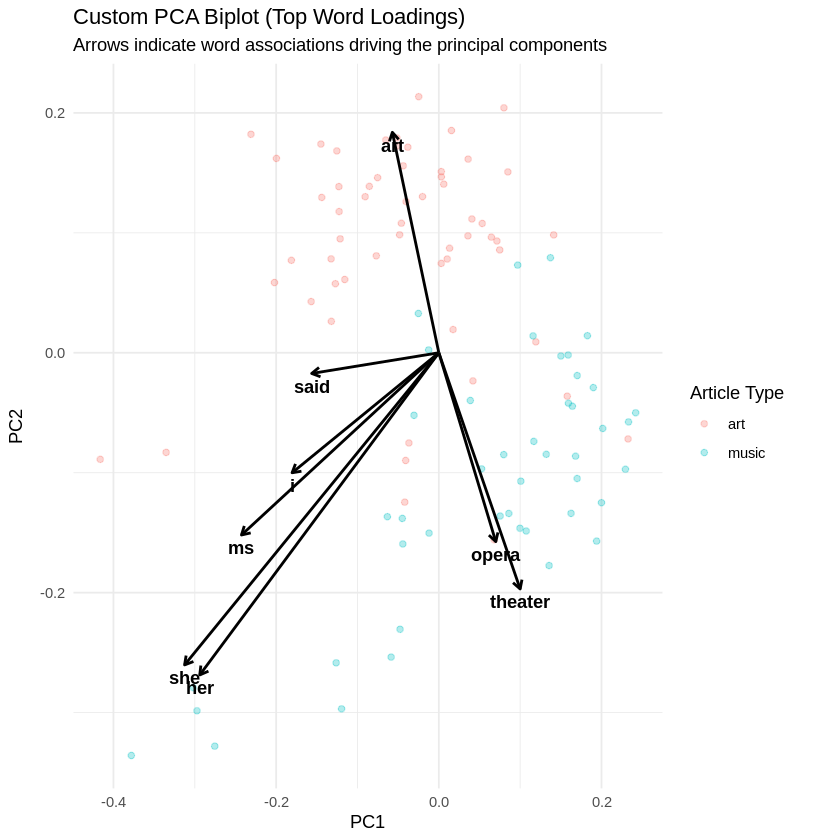

In [10]:
# 1. convert to dataframe AND safely save the row names as a new column called 'word'
loadings <- as.data.frame(pca_unscaled$rotation) %>%
  rownames_to_column(var = "word")

# 2. select variables with the largest absolute loadings on PC1 and PC2
top_pc1 <- loadings %>% arrange(desc(abs(PC1))) %>% head(5) %>% pull(word)
top_pc2 <- loadings %>% arrange(desc(abs(PC2))) %>% head(5) %>% pull(word)
top_vars <- unique(c(top_pc1, top_pc2)) # to get a list of the top words

# subset the loadings to only include these top words
subset_loadings <- loadings %>% filter(word %in% top_vars)

# 3. scale the loadings (So the arrows fit nicely on the plot)
scale_mult <- min(max(abs(pca_data_unscaled$PC1)) / max(abs(subset_loadings$PC1)),
                  max(abs(pca_data_unscaled$PC2)) / max(abs(subset_loadings$PC2))) * 0.8

# 4. plot the custom biplot
ggplot() +
  geom_point(data = pca_data_unscaled, aes(x = PC1, y = PC2, color = class_labels), alpha = 0.3) +

  # plot the arrows (axes) for the top words
  geom_segment(data = subset_loadings,
               aes(x = 0, y = 0, xend = PC1 * scale_mult, yend = PC2 * scale_mult),
               arrow = arrow(length = unit(0.2, "cm")), color = "black", linewidth = 0.8) +

  # add the text labels for the words
  geom_text(data = subset_loadings,
            aes(x = PC1 * scale_mult, y = PC2 * scale_mult, label = word),
            vjust = 1.5, color = "black", fontface = "bold") +
  theme_minimal() +
  labs(title = "Custom PCA Biplot (Top Word Loadings)",
       subtitle = "Arrows indicate word associations driving the principal components",
       x = "PC1", y = "PC2",
       color = "Article Type")

#III. Heart Disease Dataset Analysis Using Mosaic Plots and Cotabplots (20 Points)

1. Mosaic Plots: Predictors vs. HeartDisease

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



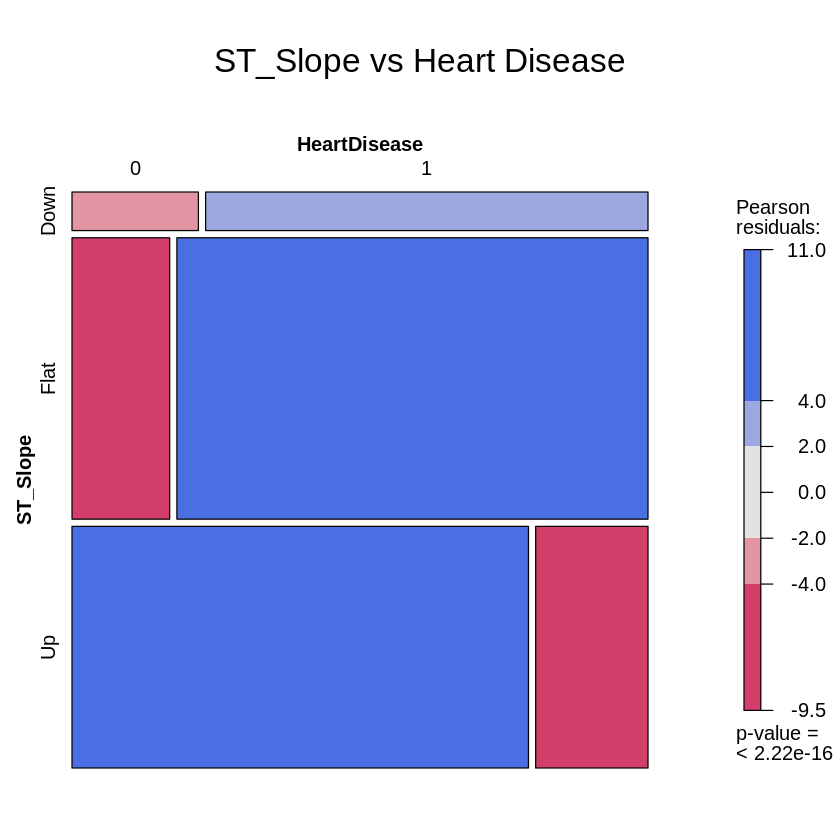

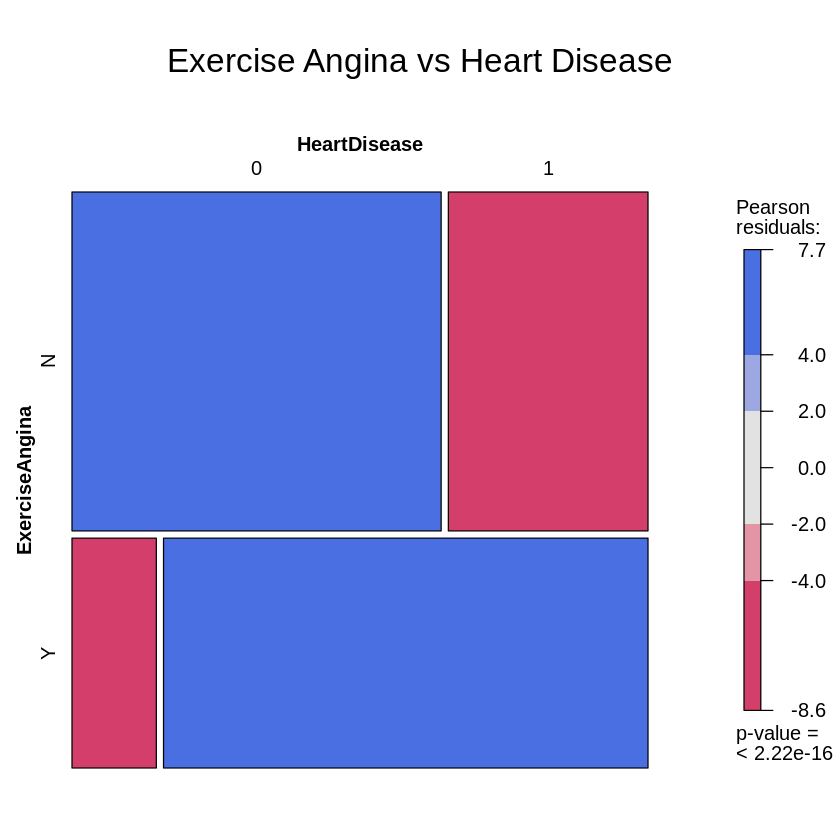

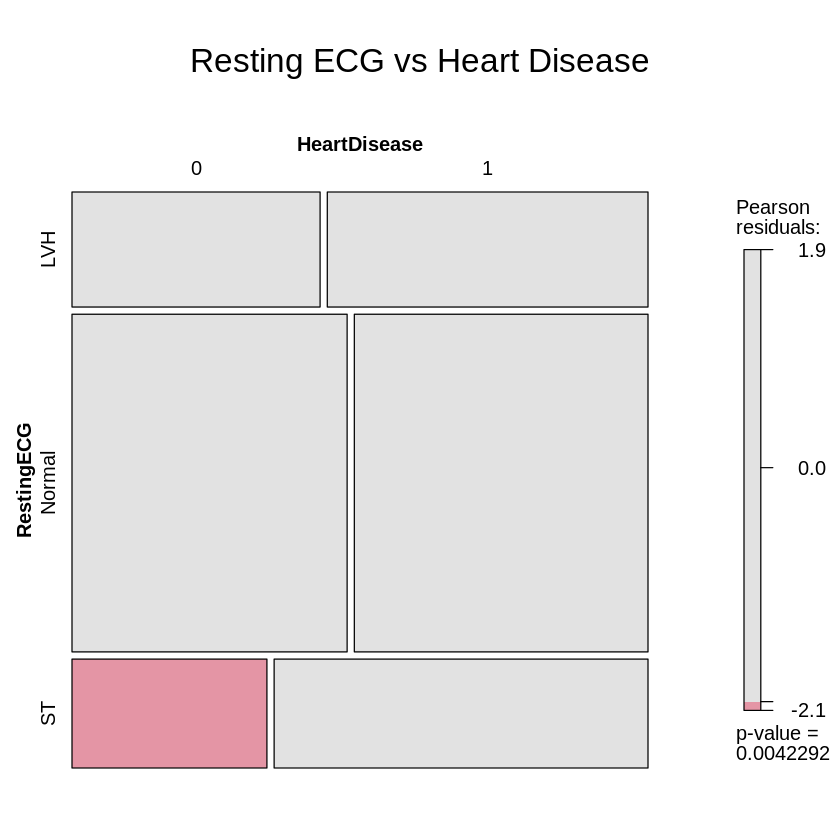

In [14]:
install.packages("vcd")
library(tidyverse)
library(vcd)

df <- read.csv("/content/heart-1.csv")
df$HeartDisease <- as.factor(df$HeartDisease)

# The shade = TRUE argument colors the boxes based on statistical significance (Pearson residuals)
mosaic(~ ST_Slope + HeartDisease, data = df, shade = TRUE,
       main = "ST_Slope vs Heart Disease")

mosaic(~ ExerciseAngina + HeartDisease, data = df, shade = TRUE,
       main = "Exercise Angina vs Heart Disease")

mosaic(~ RestingECG + HeartDisease, data = df, shade = TRUE,
       main = "Resting ECG vs Heart Disease")

2. Relationships Among Predictors

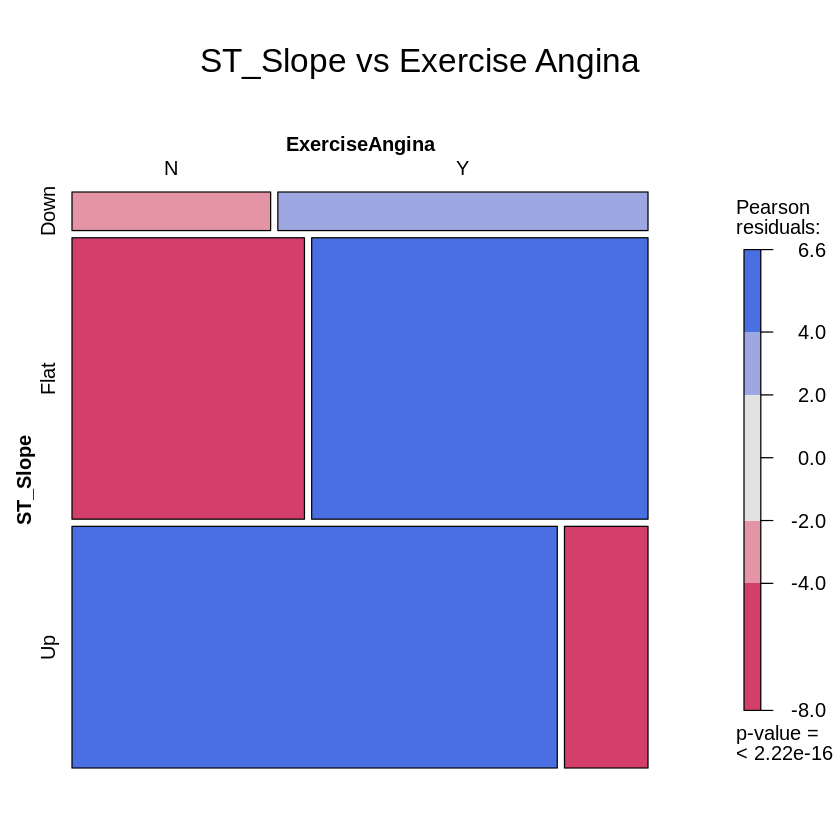

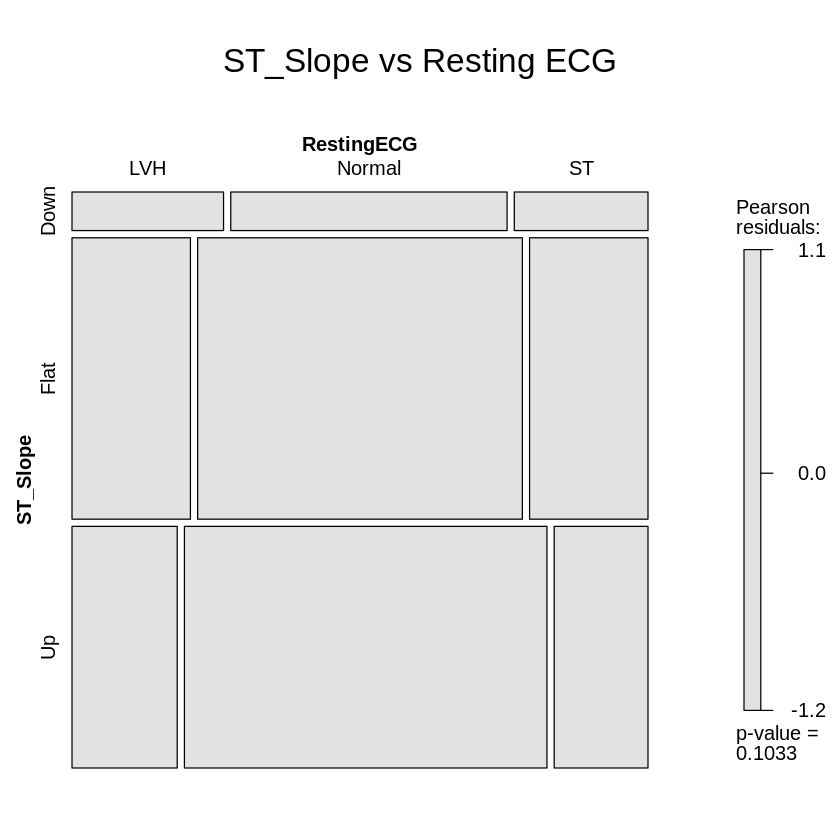

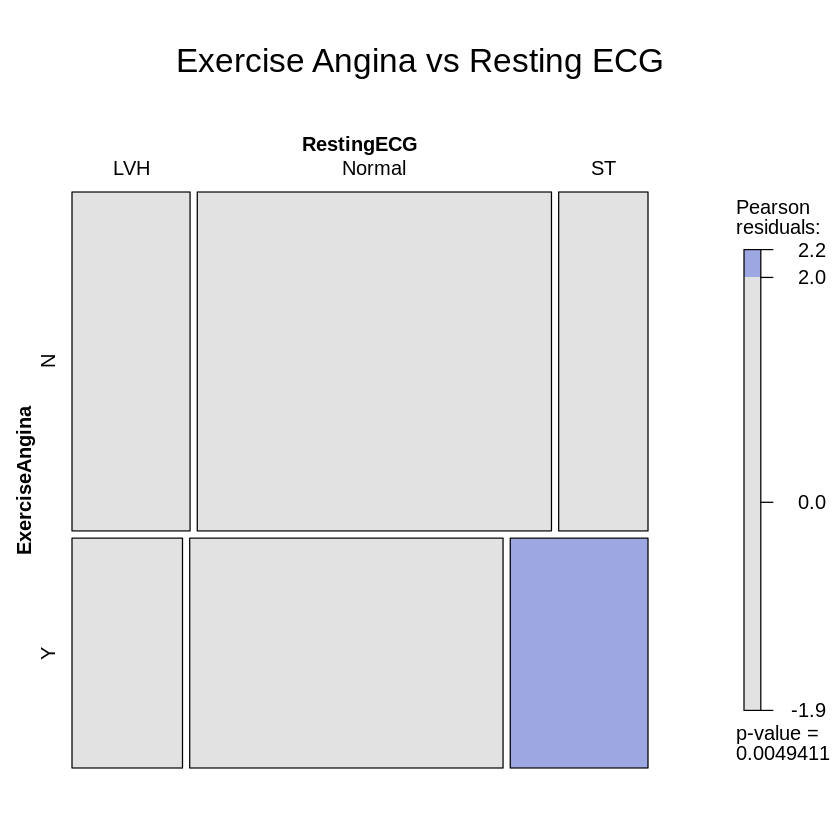

In [15]:
mosaic(~ ST_Slope + ExerciseAngina, data = df, shade = TRUE,
       main = "ST_Slope vs Exercise Angina")

mosaic(~ ST_Slope + RestingECG, data = df, shade = TRUE,
       main = "ST_Slope vs Resting ECG")

mosaic(~ ExerciseAngina + RestingECG, data = df, shade = TRUE,
       main = "Exercise Angina vs Resting ECG")

3. Cotabplot Investigation

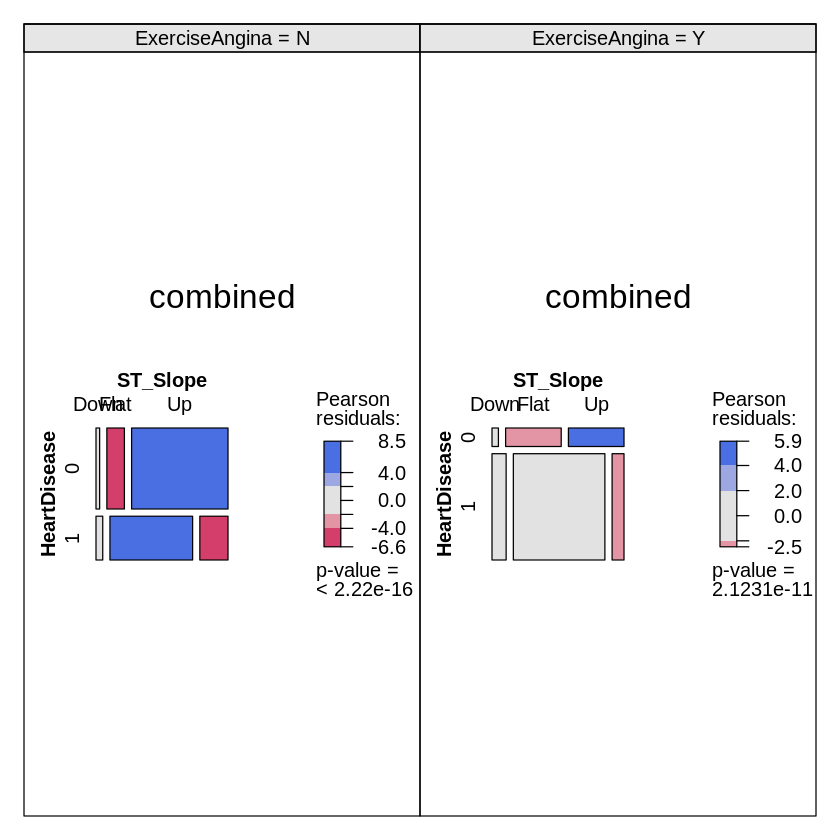

In [17]:
cotabplot(~ HeartDisease + ST_Slope | ExerciseAngina, data = df, shade = TRUE,
          main = "combined")